# Objectives - Diabetes Classification (Y/N) & Clustering
Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
1. Data preprocessing 
2. Exploratory data analysis (EDA)
3. Model selection
4. Model training
5. Hyperparameter tuning
6. Feature importance (permutation-based and SHAP)
7. KMeans Clustering of top features


# Libraries and dependencies

In [1]:
pip install -r requirements.txt

  Using cached numpy-2.2.5-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.1-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.15.2-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached xgboost-3.0.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached shap-0.47.2-cp312-cp312-win_amd64.whl.metadata (25 kB)
  Using cached typing_extensions-4.13.2-py3-none-any.whl.metadata (3.0 kB)
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
  Using cached numba-0.61.2-cp312-cp312-win_amd64.whl.metadata (2.9 kB)
Using cached numpy-2.2.5-cp312-cp312-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.10.1-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached scipy-1.15.2-cp312-cp312-win_amd64.whl (40.9 MB)
Using cached xgboost-3.0.0-py3-none-win_amd64.whl (150.0 MB)
Using cached shap-0.47.2-cp312-cp312-win_amd64.whl (545 kB)
Using cached numba-0.61.2-cp312-cp312-win_am

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.2.5 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.inspection import permutation_importance

# Hyperparameter Tuning
from skopt import BayesSearchCV
from skopt.space import Integer, Real

# Explainability
import shap

# Clustering
from sklearn.cluster import KMeans

c:\Users\nigel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load dataset

In [3]:
# Define the path correctly
dataset_path = "data/diabetes.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(dataset_path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Distribution of the 2 classes in Outcome column
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Preprocessing

## Exploratory Data Analysis (EDA)

In [8]:
# List of continuous numerical columns
X = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

In [9]:
def plot_histograms(df, columns, title='Histograms for Numerical Columns'):
    """
    Plots histograms for the specified numerical columns in a DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        columns (list): List of numerical column names to plot.
        title (str): Title for the entire figure.
    """
    num_cols = len(columns)
    n_rows = (num_cols // 3) + (num_cols % 3 > 0)
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=16)
    
    axes = axes.flatten()
    
    for i, column in enumerate(columns):
        axes[i].hist(df[column].dropna(), bins=30, edgecolor='black', color='#4682B4')
        axes[i].set_title(column, fontsize = 14)
        axes[i].set_xlabel(column, fontsize = 14)
        axes[i].set_ylabel('Frequency')
    
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


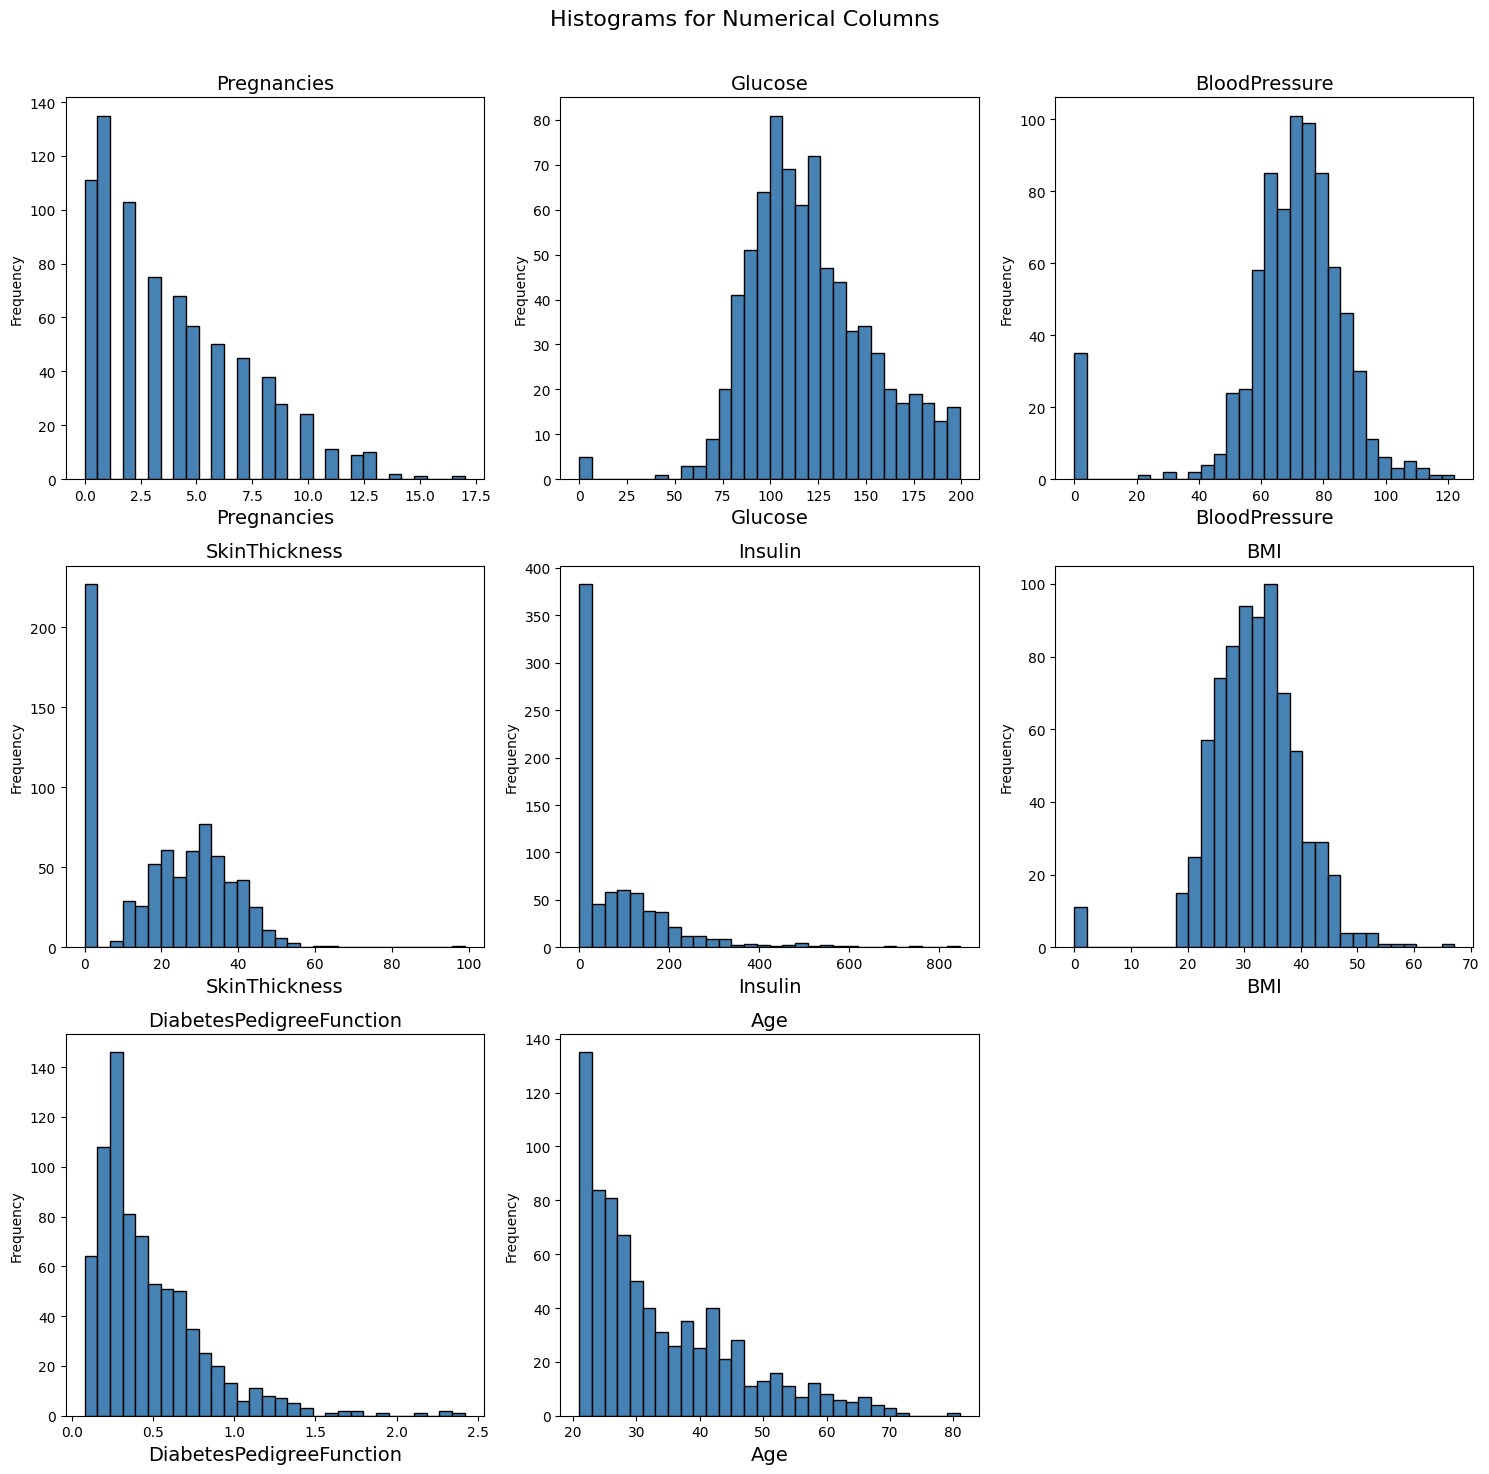

In [10]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

## Replace 0 in appropriate columns with median

In [11]:
# List of columns where 0 is invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN first
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Impute NaNs with median based on Outcome (0 = non-diabetic, 1 = diabetic)
for col in invalid_zero_cols:
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))


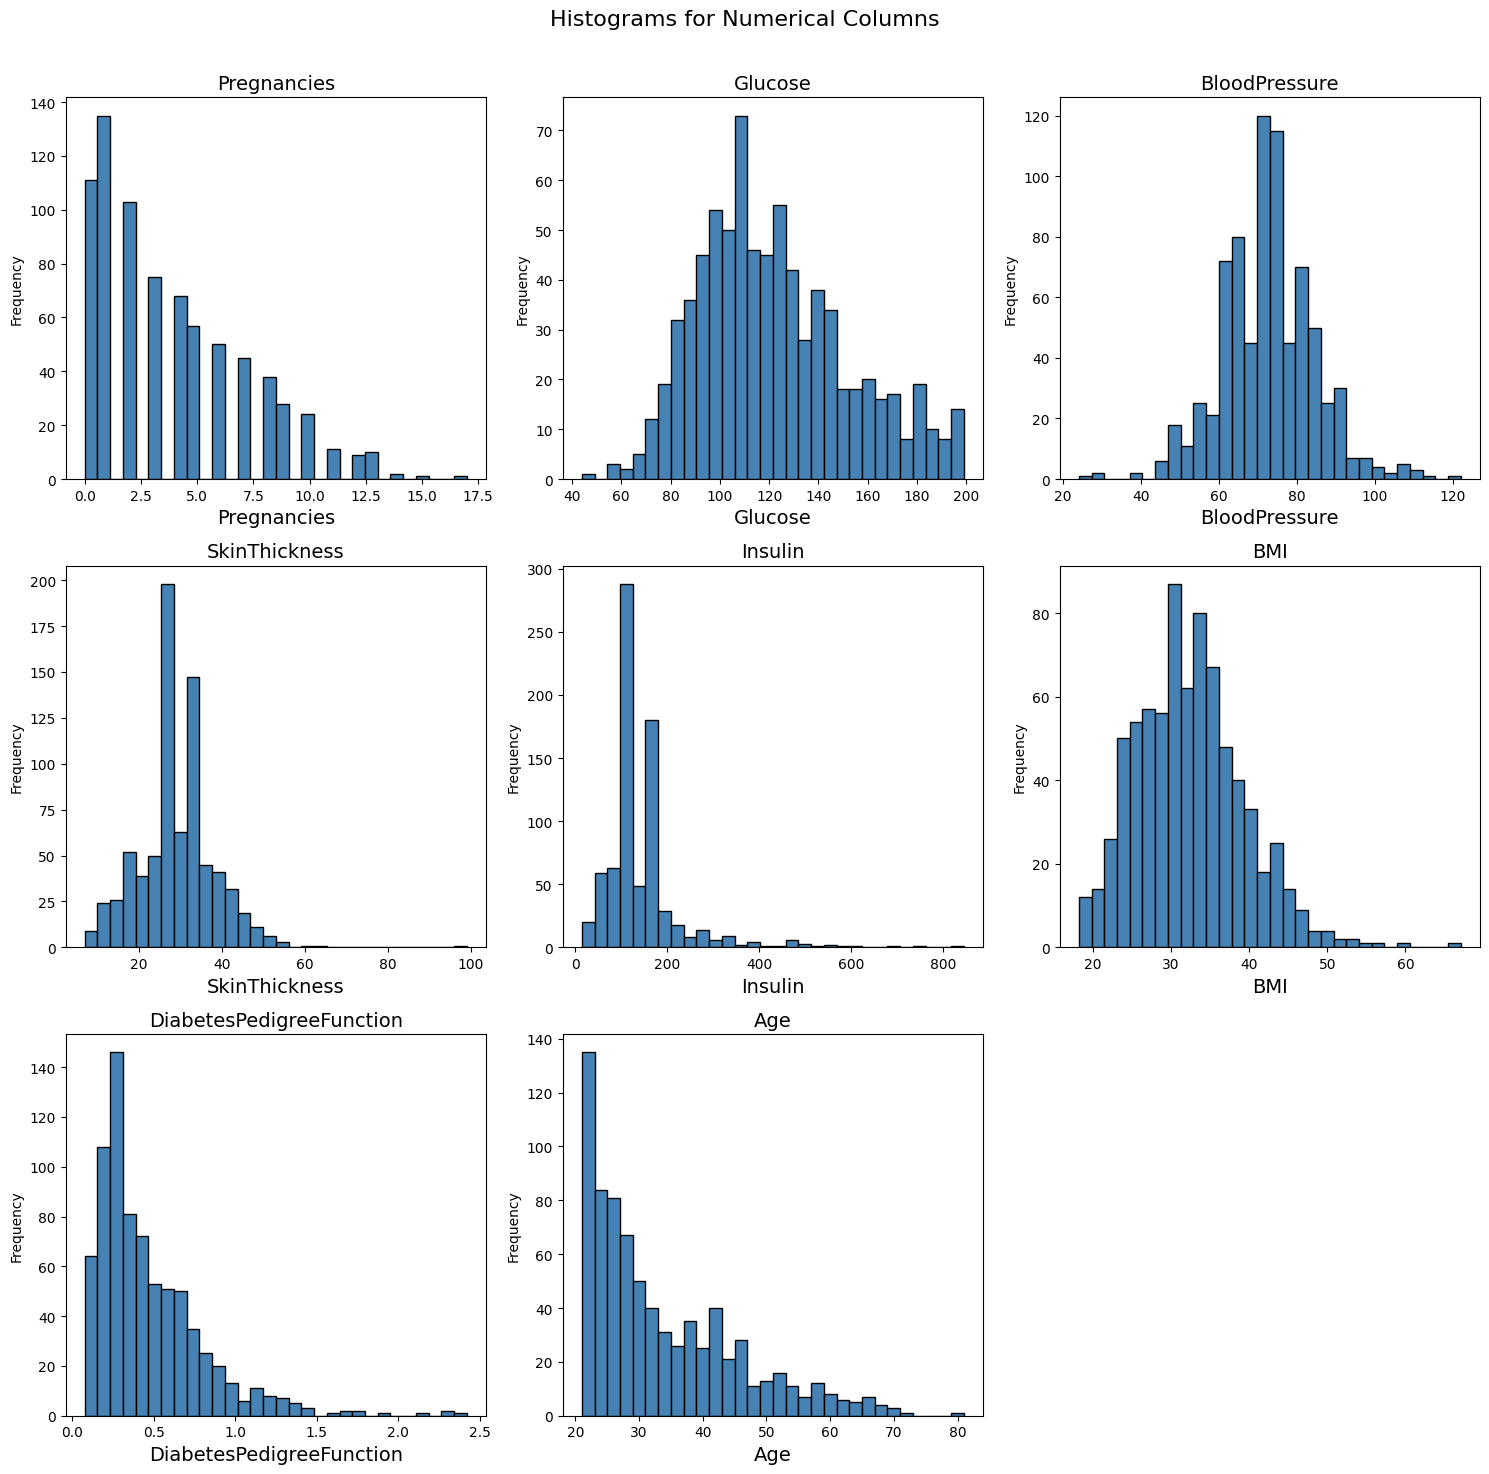

In [12]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

## Skewness of features

In [13]:
# Print skewness for each numerical column in your DataFrame
print("Skewness of each column:\n")
print(df[X].skew().sort_values(ascending=False))

Skewness of each column:

Insulin                     3.028046
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
SkinThickness               0.817477
BMI                         0.606416
Glucose                     0.532324
BloodPressure               0.140830
dtype: float64


## Remove outliers using z-score and IQR

In [14]:
# Columns for IQR filtering
iqr_cols = ['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction', 'Age']

# Columns for Z-score filtering (the rest of X)
zscore_cols = [col for col in X if col not in iqr_cols]

# IQR Filtering
iqr_mask = pd.Series([True] * len(df))
for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_mask &= df[col].between(lower, upper)

# Z-score Filtering
z_scores = np.abs(zscore(df[zscore_cols]))
zscore_mask = (z_scores <= 3).all(axis=1)

# Combined Mask
combined_mask = iqr_mask & zscore_mask

# Apply the combined mask
df_no_outliers = df[combined_mask].reset_index(drop=True)

print(f"Outliers removed: {len(df) - len(df_no_outliers)} rows dropped")


Outliers removed: 101 rows dropped


In [15]:
# Check skewness of numerical columns after outlier removal
skew_values = df_no_outliers[X].skew()
print(skew_values)


Pregnancies                 0.828383
Glucose                     0.607425
BloodPressure               0.177852
SkinThickness               0.123061
Insulin                     0.367558
BMI                         0.374673
DiabetesPedigreeFunction    0.980083
Age                         1.057780
dtype: float64


In [16]:
df_no_outliers.count()

Pregnancies                 667
Glucose                     667
BloodPressure               667
SkinThickness               667
Insulin                     667
BMI                         667
DiabetesPedigreeFunction    667
Age                         667
Outcome                     667
dtype: int64

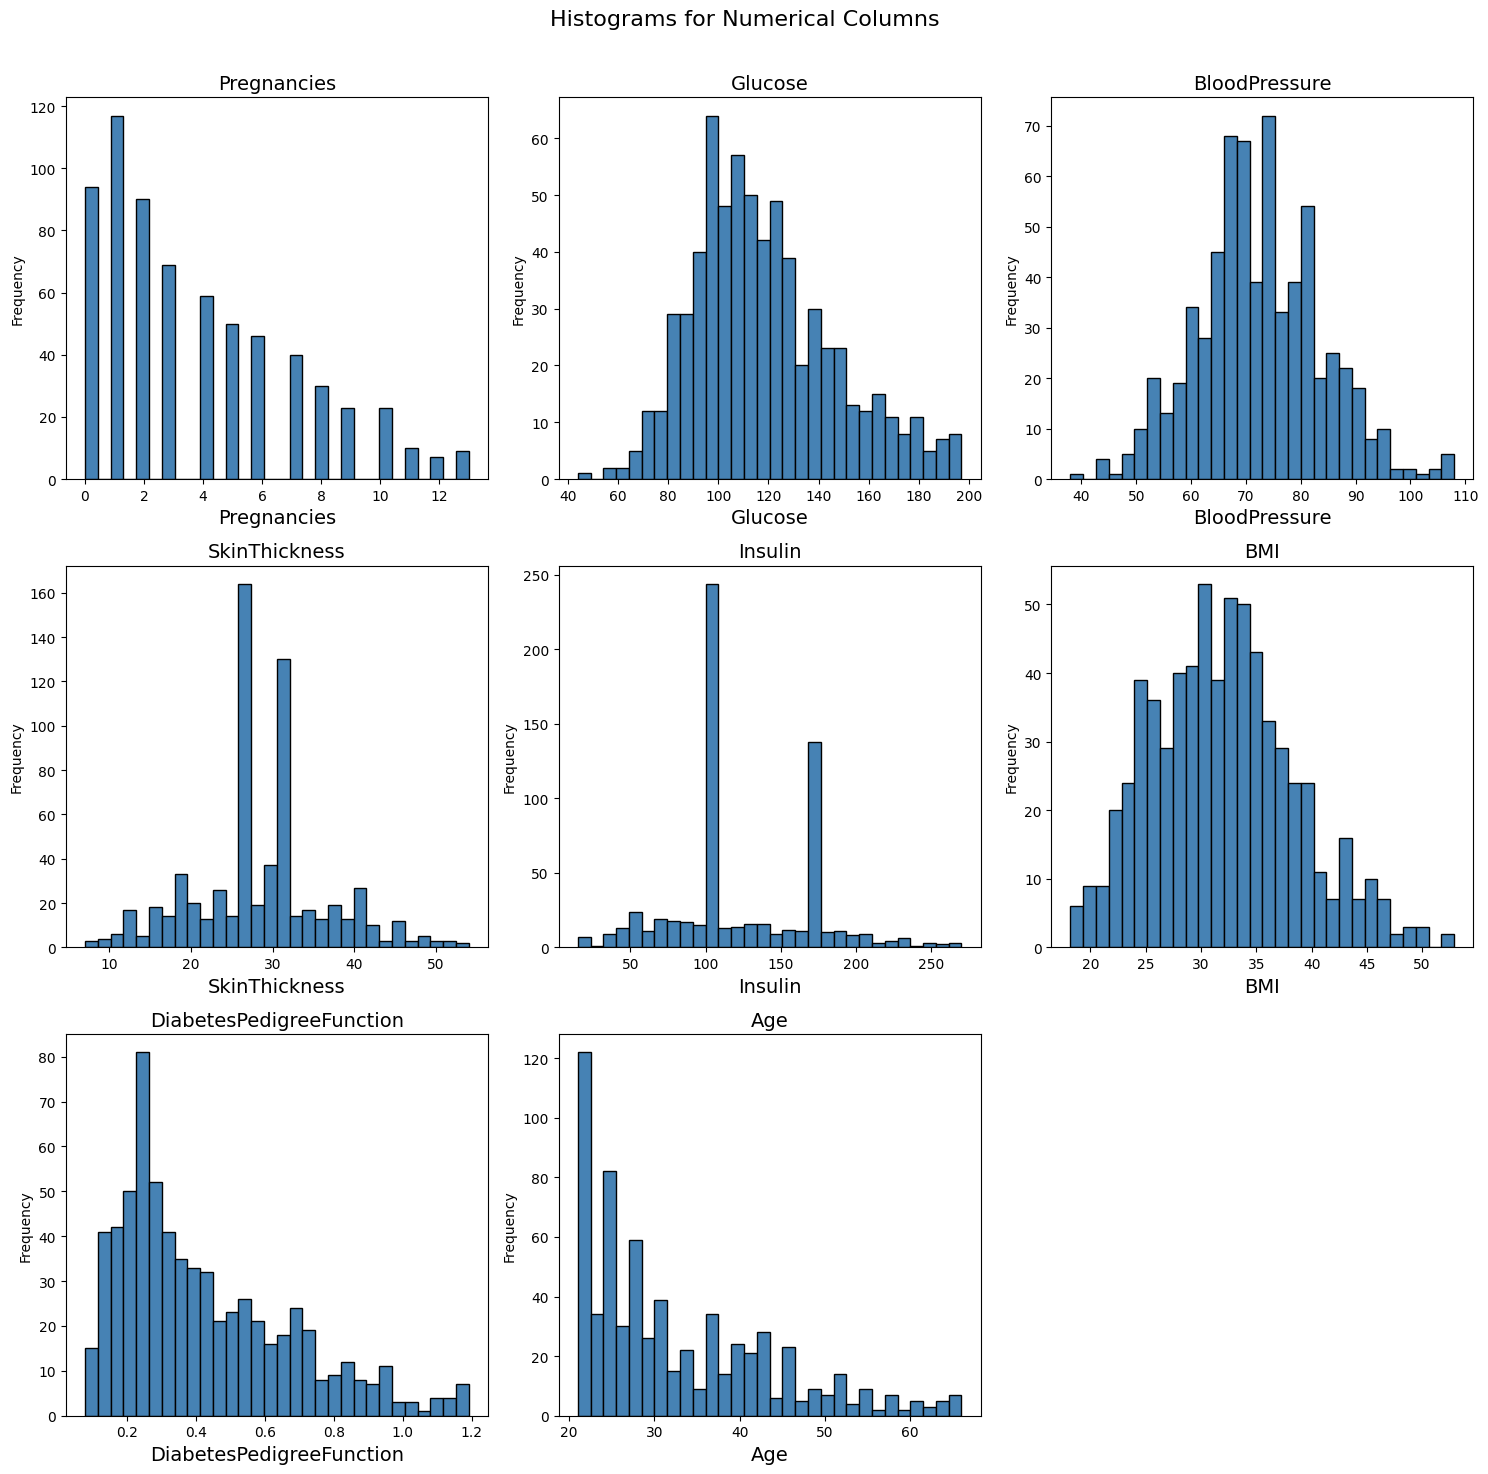

In [17]:
plot_histograms(df_no_outliers, X, title='Histograms for Numerical Columns')

## Pearson correlation heatmap

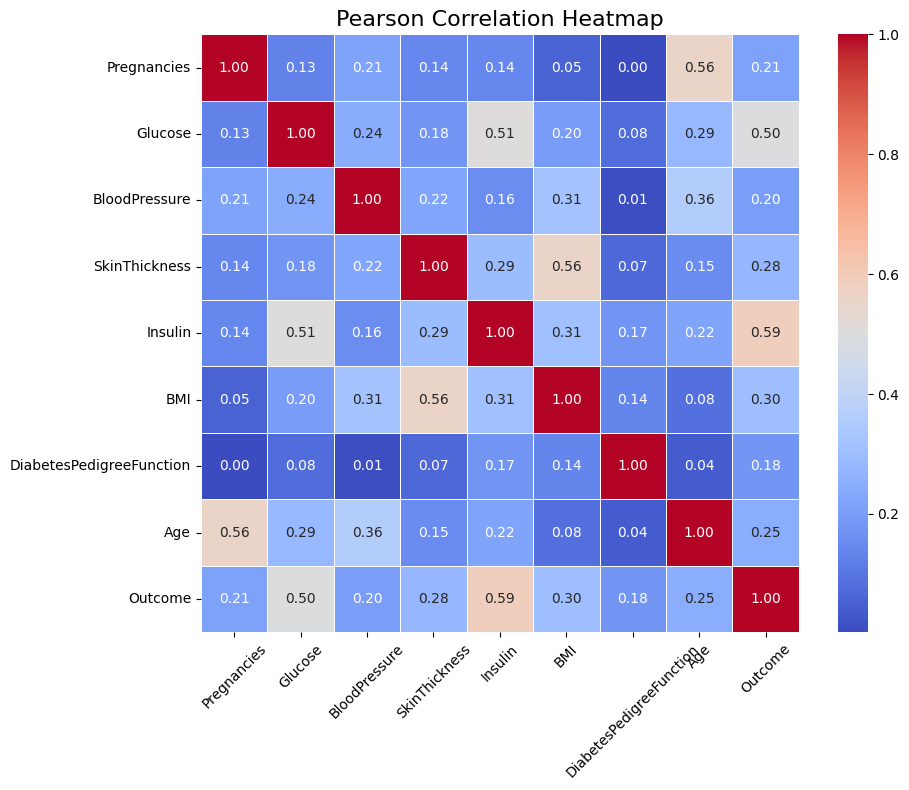

In [18]:
# Compute the Pearson correlation matrix
corr_matrix = df_no_outliers.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Model training

## Train-test split

In [19]:
# Step 1: Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Step 2: Perform stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Print shapes to confirm
print("Dataset split:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")


Dataset split:
X_train: (533, 8), y_train: (533,)
X_test:  (134, 8), y_test:  (134,)


## Scaling

In [20]:
# Step 3: Initialize the scaler
scaler = StandardScaler()

# Step 4: Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## SMOTE 

In [21]:
# Step 5: Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Check class distribution after SMOTE
print("Class distribution after SMOTE:")
print(y_train_sm.value_counts())


Class distribution after SMOTE:
Outcome
0    363
1    363
Name: count, dtype: int64


# Results

## Model performance

In [22]:
# Define models with default hyperparameters
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "kNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "ANN (MLPClassifier)": MLPClassifier(random_state=42, max_iter=1000)
}

# Store results
results = []

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)

    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc0 = roc_auc_score(y_test, y_proba) 

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'AUC': auc0
    })

# Convert to DataFrame and sort
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

# Get top 3 by F1-Score
top3_df = results_df.head(3)

# Display results
print("All Model Results:\n", results_df)
print("\nTop 3 Models by F1-Score:\n", top3_df)


c:\Users\nigel\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:37:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


All Model Results:
                  Model  Accuracy  Precision    Recall  F1-Score       AUC
7             AdaBoost  0.925373   0.923077  0.837209  0.878049  0.961283
5        Random Forest  0.917910   0.880952  0.860465  0.870588  0.949655
8              XGBoost  0.917910   0.921053  0.813953  0.864198  0.967544
6    Gradient Boosting  0.910448   0.897436  0.813953  0.853659  0.967289
9  ANN (MLPClassifier)  0.902985   0.875000  0.813953  0.843373  0.922310
2                  SVM  0.888060   0.804348  0.860465  0.831461  0.901610
3          Naive Bayes  0.880597   0.787234  0.860465  0.822222  0.917199
4                  kNN  0.873134   0.782609  0.837209  0.808989  0.907105
0  Logistic Regression  0.865672   0.777778  0.813953  0.795455  0.899310
1        Decision Tree  0.850746   0.794872  0.720930  0.756098  0.816509

Top 3 Models by F1-Score:
            Model  Accuracy  Precision    Recall  F1-Score       AUC
7       AdaBoost  0.925373   0.923077  0.837209  0.878049  0.961283
5 

c:\Users\nigel\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Hyperparamater tuning

In [23]:
# Stratified K-Fold setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. AdaBoost
ab_search = BayesSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    search_spaces={
        'n_estimators': Integer(50, 300),
        'learning_rate': Real(0.01, 1.0, prior='log-uniform')
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)
ab_search.fit(X_train_sm, y_train_sm)

# 2. Random Forest
rf_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces={
        'n_estimators': Integer(100, 400),
        'max_depth': Integer(5, 30),
        'min_samples_split': Integer(2, 20),
        'min_samples_leaf': Integer(1, 10),
        'max_features': Real(0.1, 1.0),
        'bootstrap': [True, False],
        'min_impurity_decrease': Real(0.0, 0.1),
        'max_leaf_nodes': Integer(10, 100)
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)
rf_search.fit(X_train_sm, y_train_sm)

# 3. XGBoost
xgb_search = BayesSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    search_spaces={
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(3, 15),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'subsample': Real(0.5, 1.0),
        'colsample_bytree': Real(0.5, 1.0)
    },
    cv=cv_strategy,
    n_iter=30,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)
xgb_search.fit(X_train_sm, y_train_sm)

# Print Iteration Logs
def print_search_progress(search_obj, model_name):
    print(f"\n Iteration Progress for {model_name}:")
    results_df = pd.DataFrame(search_obj.cv_results_)
    for i, row in results_df.iterrows():
        print(f"Iteration {i+1:2}: AUC = {row['mean_test_score']:.4f}, Params = {row['params']}")

    print(f"Best {model_name} Params:\n", search_obj.best_params_)
    print(f"Best AUC Score: {search_obj.best_score_:.4f}\n")

print_search_progress(ab_search, "AdaBoost")
print_search_progress(rf_search, "Random Forest")
print_search_progress(xgb_search, "XGBoost")


c:\Users\nigel\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:38:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Iteration Progress for AdaBoost:
Iteration  1: AUC = 0.9418, Params = OrderedDict({'learning_rate': 0.06610098295419149, 'n_estimators': 232})
Iteration  2: AUC = 0.9582, Params = OrderedDict({'learning_rate': 0.4729080547055919, 'n_estimators': 271})
Iteration  3: AUC = 0.9442, Params = OrderedDict({'learning_rate': 0.07756486208064789, 'n_estimators': 280})
Iteration  4: AUC = 0.9533, Params = OrderedDict({'learning_rate': 0.42149456283334996, 'n_estimators': 93})
Iteration  5: AUC = 0.9553, Params = OrderedDict({'learning_rate': 0.3972893133963027, 'n_estimators': 160})
Iteration  6: AUC = 0.9553, Params = OrderedDict({'learning_rate': 0.29380287142759304, 'n_estimators': 285})
Iteration  7: AUC = 0.9512, Params = OrderedDict({'learning_rate': 0.1714583803805369, 'n_estimators': 244})
Iteration  8: AUC = 0.9500, Params = OrderedDict({'learning_rate': 0.12212543829922852, 'n_estimators': 280})
Iteration  9: AUC = 0.9573, Params = OrderedDict({'learning_rate': 0.8146216961026963, 'n

In [24]:
# Define fine-tuned models
tuned_models = {
    "Tuned AdaBoost": ab_search.best_estimator_,
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned XGBoost": xgb_search.best_estimator_,
}

# Store tuned results
tuned_results = []

for name, model in tuned_models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc1 = roc_auc_score(y_test, y_proba) # auc1 because dont want to overwrite auc
    report = classification_report(y_test, y_pred, output_dict=True)

    tuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'AUC': auc1
    })

# Convert to DataFrame
tuned_df = pd.DataFrame(tuned_results).sort_values(by="F1-Score", ascending=False)

# Concatenate for comparison
comparison_df = pd.concat([top3_df, tuned_df], ignore_index=True)

# Display
print("Comparison: Top 3 Default Models vs Fine-Tuned Models")
print(comparison_df)


Comparison: Top 3 Default Models vs Fine-Tuned Models
                 Model  Accuracy  Precision    Recall  F1-Score       AUC
0             AdaBoost  0.925373   0.923077  0.837209  0.878049  0.961283
1        Random Forest  0.917910   0.880952  0.860465  0.870588  0.949655
2              XGBoost  0.917910   0.921053  0.813953  0.864198  0.967544
3       Tuned AdaBoost  0.932836   0.925000  0.860465  0.891566  0.967289
4  Tuned Random Forest  0.925373   0.883721  0.883721  0.883721  0.960133
5        Tuned XGBoost  0.925373   0.923077  0.837209  0.878049  0.969844


c:\Users\nigel\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:38:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## ROC curve

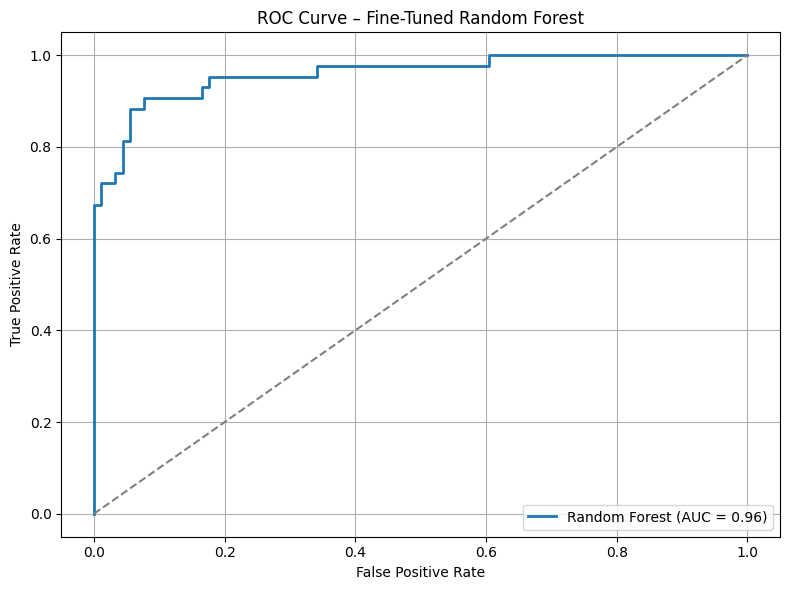

In [25]:
# Get predicted probabilities for class 1
y_proba_rf = rf_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Fine-Tuned Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# Model interpretation

## Sample tree

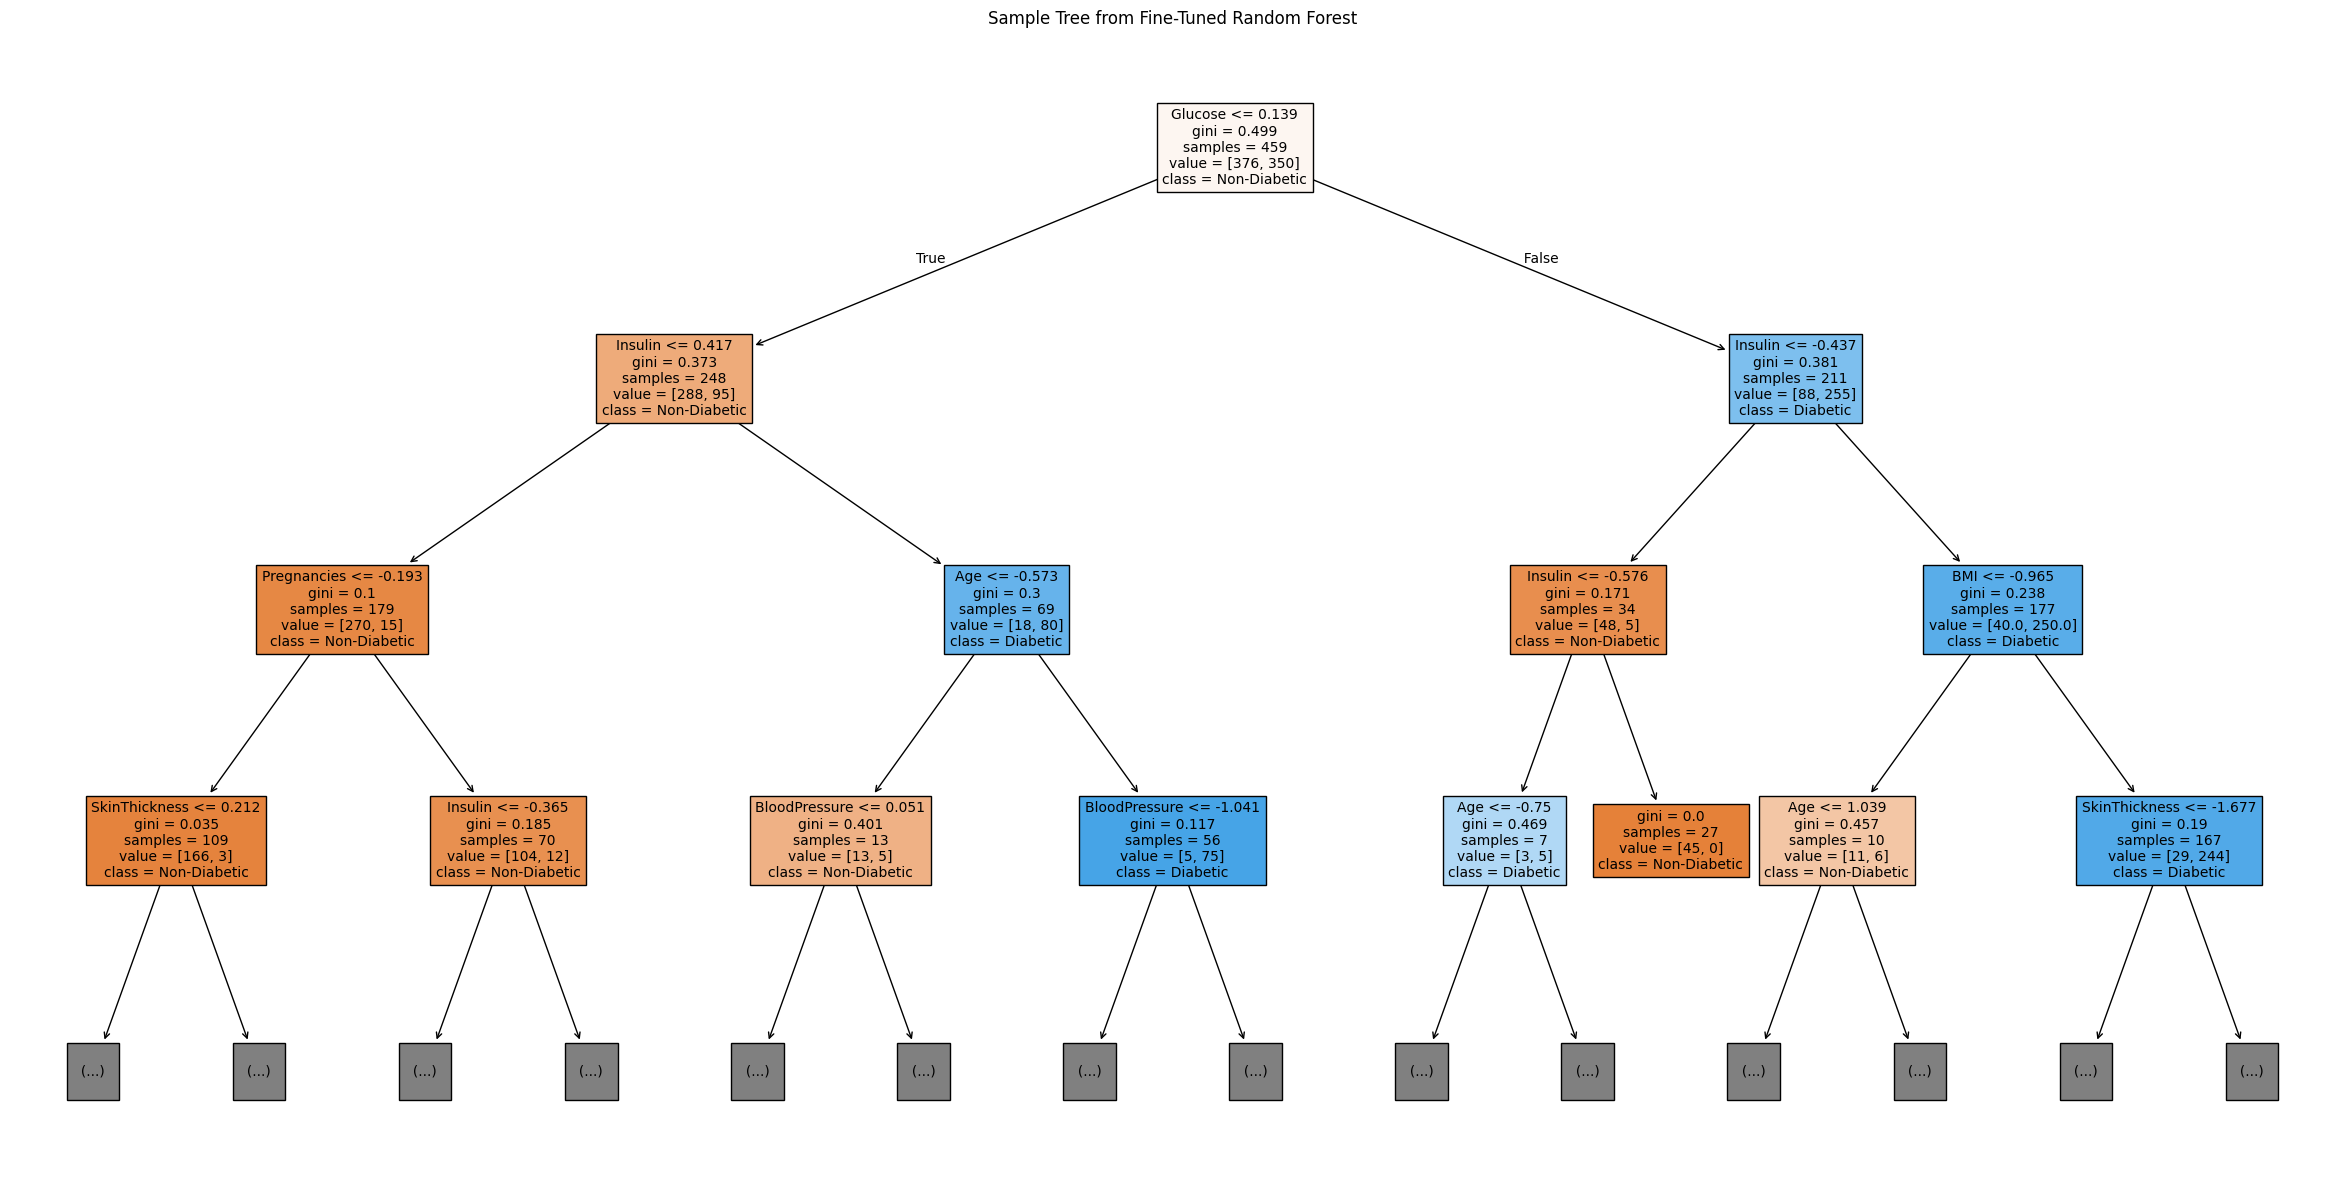

In [26]:
# Get the first tree from the forest
single_tree = rf_search.best_estimator_.estimators_[0]

# Plot the tree (limited depth for readability)
plt.figure(figsize=(30, 15))
plot_tree(single_tree,
          feature_names=X_train.columns,  # Or list of feature names
          class_names=["Non-Diabetic", "Diabetic"],
          filled=True,
          max_depth=3,  # Adjust as needed
          fontsize=10)
plt.title("Sample Tree from Fine-Tuned Random Forest")
plt.show()


## Feature Importance (Permutation-Based)

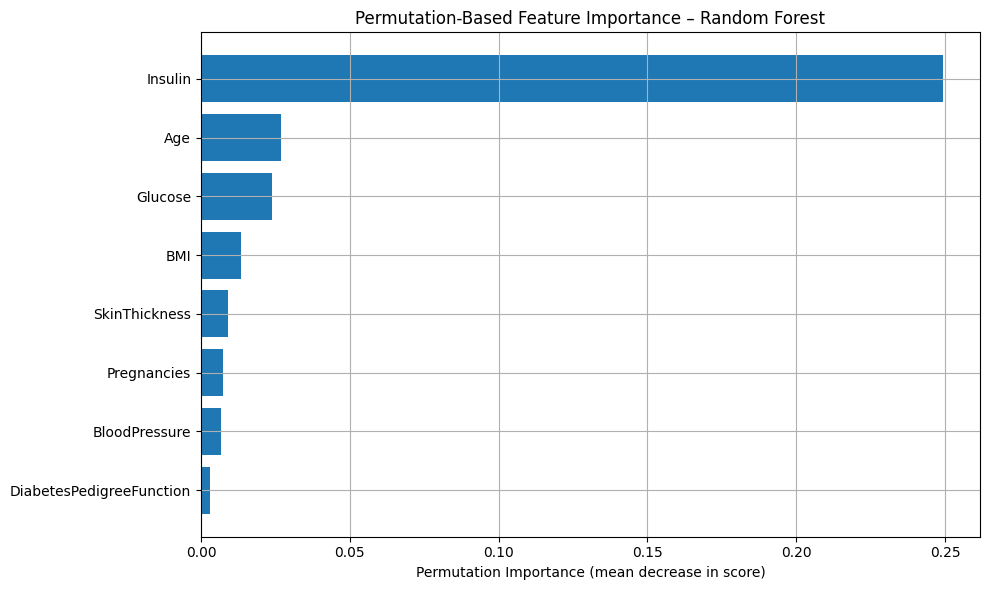

In [27]:
# Evaluate permutation importance on test data
result = permutation_importance(
    rf_search.best_estimator_, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Convert to DataFrame
perm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance (Mean)': result.importances_mean,
    'Importance (Std)': result.importances_std
}).sort_values(by='Importance (Mean)', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'], perm_df['Importance (Mean)'])
plt.gca().invert_yaxis()
plt.xlabel('Permutation Importance (mean decrease in score)')
plt.title('Permutation-Based Feature Importance – Random Forest')
plt.grid(True)
plt.tight_layout()
plt.show()


## SHAP importance

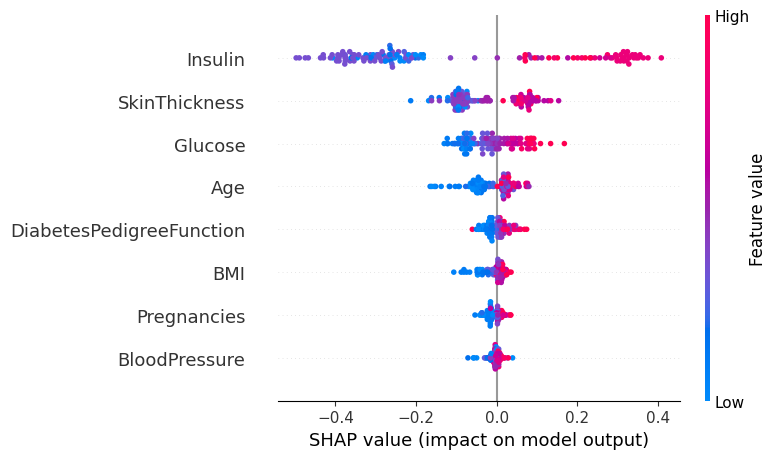

In [28]:
# Make sure X_test_scaled_df is a DataFrame with proper shape and column names
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# Create TreeExplainer
explainer = shap.TreeExplainer(rf_search.best_estimator_)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_scaled_df)

# Use the SHAP values for class 1 (diabetic)
shap.summary_plot(shap_values[:, :, 1], X_test_scaled_df)


## KMeans Clustering

In [29]:
# Select top features for clustering
clustering_data = X_test_scaled_df[['Insulin', 'SkinThickness', 'Glucose']].copy()


In [30]:
# Fit KMeans with 4 clusters (tune this if needed)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(clustering_data)

# Add cluster labels
clustering_data['Cluster'] = clusters


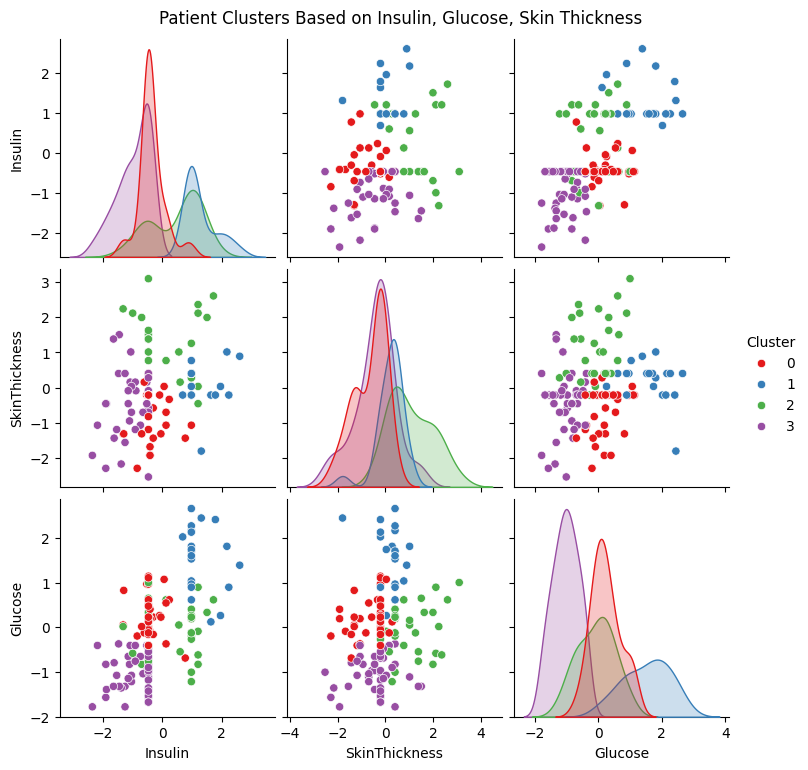

In [31]:
# Pairplot to explore relationships across clusters
sns.pairplot(clustering_data, hue='Cluster', palette='Set1', diag_kind='kde')
plt.suptitle("Patient Clusters Based on Insulin, Glucose, Skin Thickness", y=1.02)
plt.show()


In [32]:
# Add target labels back (assumes y_test is aligned with X_test_scaled_df)
clustering_data['Outcome'] = y_test.reset_index(drop=True)

# Look at diabetes rate per cluster
cluster_summary = clustering_data.groupby('Cluster')['Outcome'].agg(['count', 'mean'])
cluster_summary.columns = ['Count', 'Diabetes Rate']
print(cluster_summary)


         Count  Diabetes Rate
Cluster                      
0           37       0.135135
1           22       0.863636
2           30       0.533333
3           45       0.066667
